# Does Visual-Language Context Improve Action Recognition?
## Evaluating Qwen2-VL 7B on UCF-101

**Three conditions:**
- **Condition A** — Video frames only (zero-shot baseline)
- **Condition B** — Video frames + ground truth label as context (oracle upper bound)
- **Condition C** — Video frames + wrong label as context (noise injection control)

**Research question:** Does providing accurate action context improve VLM performance — and does the model genuinely use that context or ignore it?

**Dataset:** UCF-101 — 101 action classes, videos organized by class folder  
**Model:** Qwen2-VL 7B  
**Hardware:** T4 16GB GPU (Kaggle free tier)

## 1. Setup

In [1]:
import subprocess, sys
def install(pkg):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg])

install('transformers>=4.37.0')
install('accelerate')
install('qwen-vl-utils')
install('opencv-python-headless')
for pkg in ['Pillow', 'pandas', 'numpy', 'matplotlib', 'scipy', 'tqdm']:
    install(pkg)
print('Done')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.2/41.2 MB 52.3 MB/s eta 0:00:00
Done


In [2]:
import os, random
import numpy as np
import pandas as pd
import torch
import cv2
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm
from pathlib import Path
from scipy.stats import chi2
from transformers import Qwen2VLForConditionalGeneration, AutoProcessor

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if torch.cuda.is_available():
    print(f'GPU : {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

Device: cuda
GPU : Tesla T4
VRAM: 15.6 GB


## 2. UCF-101 Dataset
Ground truth label = folder name. No annotation file needed.

In [3]:
import os
base = '/kaggle/input/datasets/matthewjansen/ucf101-action-recognition'
print(os.listdir(base))

['val.csv', 'val', 'train.csv', 'test.csv', 'test', 'train']


In [5]:
def build_sample_list(ucf_root, n_per_class=1, seed=42):
    random.seed(seed)
    samples = []
    for class_dir in sorted(ucf_root.iterdir()):
        if not class_dir.is_dir():
            continue
        videos = list(class_dir.glob('*.avi'))
        if not videos:
            continue
        selected = random.sample(videos, min(n_per_class, len(videos)))
        for v in selected:
            samples.append((v, class_dir.name))
    random.shuffle(samples)
    return samples
    
UCF_ROOT_TRAIN = Path('/kaggle/input/datasets/matthewjansen/ucf101-action-recognition/train')
UCF_ROOT_VAL   = Path('/kaggle/input/datasets/matthewjansen/ucf101-action-recognition/val')
UCF_ROOT_TEST  = Path('/kaggle/input/datasets/matthewjansen/ucf101-action-recognition/test')

# Discover classes from train (all splits share the same 101 classes)
ALL_CLASSES = sorted([d.name for d in UCF_ROOT_TRAIN.iterdir() if d.is_dir()])
print(f'Total action classes: {len(ALL_CLASSES)}')

# Sample from all three splits
samples_train = build_sample_list(UCF_ROOT_TRAIN, n_per_class=1, seed=42)
samples_val   = build_sample_list(UCF_ROOT_VAL,   n_per_class=1, seed=42)
samples_test  = build_sample_list(UCF_ROOT_TEST,  n_per_class=1, seed=42)

samples = samples_train + samples_val + samples_test
random.shuffle(samples)
print(f'Total samples: {len(samples)}')
print(f'  Train: {len(samples_train)} | Val: {len(samples_val)} | Test: {len(samples_test)}')

Total action classes: 101
Total samples: 303
  Train: 101 | Val: 101 | Test: 101


In [6]:
def extract_middle_frame(video_path):
    cap = cv2.VideoCapture(str(video_path))
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if total == 0:
        cap.release()
        return None
    cap.set(cv2.CAP_PROP_POS_FRAMES, total // 2)
    ret, frame = cap.read()
    cap.release()
    if not ret:
        return None
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    return Image.fromarray(frame_rgb)



UCF_ROOT_TRAIN = Path('/kaggle/input/datasets/matthewjansen/ucf101-action-recognition/train')
UCF_ROOT_VAL   = Path('/kaggle/input/datasets/matthewjansen/ucf101-action-recognition/val')
UCF_ROOT_TEST  = Path('/kaggle/input/datasets/matthewjansen/ucf101-action-recognition/test')

ALL_CLASSES = sorted([d.name for d in UCF_ROOT_TRAIN.iterdir() if d.is_dir()])
print(f'Total action classes: {len(ALL_CLASSES)}')

samples_train = build_sample_list(UCF_ROOT_TRAIN, n_per_class=1, seed=42)
samples_val   = build_sample_list(UCF_ROOT_VAL,   n_per_class=1, seed=42)
samples_test  = build_sample_list(UCF_ROOT_TEST,  n_per_class=1, seed=42)

samples = samples_train + samples_val + samples_test
random.shuffle(samples)
print(f'Total samples: {len(samples)}')
print(f'Train: {len(samples_train)} | Val: {len(samples_val)} | Test: {len(samples_test)}')

Total action classes: 101
Total samples: 303
Train: 101 | Val: 101 | Test: 101


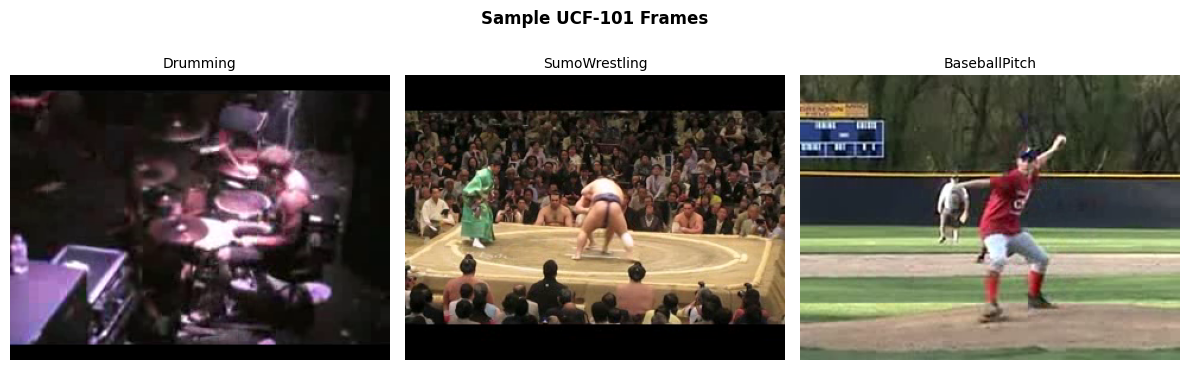

In [7]:
def get_wrong_label(correct_label, all_classes):
    """Sample a wrong label — guaranteed different from ground truth"""
    pool = [c for c in all_classes if c != correct_label]
    return random.choice(pool)

# Quick sanity check — show 3 sample frames
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for i, ax in enumerate(axes):
    video_path, label = samples[i]
    frame = extract_middle_frame(video_path)
    if frame:
        ax.imshow(frame)
        ax.set_title(label, fontsize=10)
    ax.axis('off')
plt.suptitle('Sample UCF-101 Frames', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/sample_frames.png', dpi=100)
plt.show()

## 3. Qwen2-VL 7B — Three Condition Inference

In [8]:
class Qwen2VLEvaluator:
    """
    Qwen2-VL 7B inference across three evaluation conditions.

    A: zero-shot   — raw visual understanding, no context
    B: oracle      — ground truth label as context (upper bound)
    C: noise       — wrong label as context (proves genuine context use)
    """
    def __init__(self, model_name='Qwen/Qwen2-VL-7B-Instruct'):
        print(f'Loading {model_name}...')
        self.processor = AutoProcessor.from_pretrained(
            model_name,
            min_pixels=256*28*28,
            max_pixels=1280*28*28
        )
        self.model = Qwen2VLForConditionalGeneration.from_pretrained(
            model_name,
            torch_dtype=torch.float16,
            device_map='auto'
        )
        self.model.eval()
        print('Qwen2-VL 7B ready')

    def _prompt(self, condition, gt_label=None, wrong_label=None):
        class_list = ', '.join(ALL_CLASSES)

        if condition == 'A':
            # Zero-shot: image only
            return (
                f'You are an action recognition system. '
                f'Possible action classes: {class_list}. '
                f'What action is being performed in this image? '
                f'Return only the single class name from the list above. No explanation.'
            )
        elif condition == 'B':
            # Oracle: ground truth label provided as context
            return (
                f'A reference system identified the action as: {gt_label}. '
                f'Using this context and the image, select the correct action from: {class_list}. '
                f'Return only the single class name. No explanation.'
            )
        elif condition == 'C':
            # Noise injection: wrong label as context
            return (
                f'A reference system identified the action as: {wrong_label}. '
                f'Using this context and the image, select the correct action from: {class_list}. '
                f'Return only the single class name. No explanation.'
            )

    def predict(self, image, condition, gt_label=None, wrong_label=None):
        """Run inference and return predicted class name"""
        prompt = self._prompt(condition, gt_label, wrong_label)
        messages = [{'role': 'user', 'content': [
            {'type': 'image', 'image': image},
            {'type': 'text', 'text': prompt}
        ]}]
        text = self.processor.apply_chat_template(
            messages, tokenize=False, add_generation_prompt=True
        )
        inputs = self.processor(
            text=[text], images=[image], return_tensors='pt'
        ).to(self.model.device)

        with torch.no_grad():
            out = self.model.generate(
                **inputs, max_new_tokens=50, do_sample=False
            )
        generated = self.processor.batch_decode(
            out[:, inputs.input_ids.shape[1]:],
            skip_special_tokens=True
        )[0].strip()

        return generated


model = Qwen2VLEvaluator()

Loading Qwen/Qwen2-VL-7B-Instruct...


preprocessor_config.json:   0%|          | 0.00/347 [00:00<?, ?B/s]

chat_template.json: 0.00B [00:00, ?B/s]

The image processor of type `Qwen2VLImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/730 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/244 [00:00<?, ?B/s]

Qwen2-VL 7B ready


## 4. Evaluation Framework

In [10]:
class ResultsTracker:
    """
    Tracks predictions and computes accuracy across all three conditions.
    UCF-101 is single-label — exact or fuzzy string match against class name.
    """
    def __init__(self):
        self.records = []
        self.hits = {'A': [], 'B': [], 'C': []}

    def _hit(self, predicted, ground_truth):
        """Case-insensitive substring match — handles partial class names"""
        pred = predicted.strip().lower()
        gt = ground_truth.strip().lower()
        return int(gt in pred or pred in gt or pred == gt)

    def add(self, video_path, gt_label, pred_A, pred_B, pred_C, wrong_label):
        hit_A = self._hit(pred_A, gt_label)
        hit_B = self._hit(pred_B, gt_label)
        hit_C = self._hit(pred_C, gt_label)
        self.hits['A'].append(hit_A)
        self.hits['B'].append(hit_B)
        self.hits['C'].append(hit_C)
        self.records.append({
            'video': str(video_path.name),
            'ground_truth': gt_label,
            'pred_A': pred_A, 'pred_B': pred_B, 'pred_C': pred_C,
            'wrong_label': wrong_label,
            'hit_A': hit_A, 'hit_B': hit_B, 'hit_C': hit_C
        })

    def accuracy(self, cond):
        return np.mean(self.hits[cond]) if self.hits[cond] else 0.0

    def to_dataframe(self):
        return pd.DataFrame(self.records)

    def summary(self):
        n = len(self.records)
        a, b, c = self.accuracy('A'), self.accuracy('B'), self.accuracy('C')
        print('\n' + '='*55)
        print('RESULTS — Qwen2-VL 7B on UCF-101')
        print('='*55)
        print(f'Samples evaluated    : {n}')
        print(f'A  Zero-shot         : {a:.3f}')
        print(f'B  Oracle grounded   : {b:.3f}  ({b-a:+.3f} vs A)')
        print(f'C  Noise injection   : {c:.3f}  ({c-a:+.3f} vs A)')
        print('='*55)


tracker = ResultsTracker()
print('Tracker ready')

Tracker ready


## 5. Run Evaluation

In [11]:
skipped = 0

for idx, (video_path, gt_label) in enumerate(tqdm(samples, desc='Evaluating')):

    # Extract middle frame from video
    frame = extract_middle_frame(video_path)
    if frame is None:
        skipped += 1
        continue

    # Generate wrong label for condition C
    wrong_label = get_wrong_label(gt_label, ALL_CLASSES)

    # Run all three conditions
    pred_A = model.predict(frame, 'A')
    pred_B = model.predict(frame, 'B', gt_label=gt_label)
    pred_C = model.predict(frame, 'C', wrong_label=wrong_label)

    tracker.add(video_path, gt_label, pred_A, pred_B, pred_C, wrong_label)

    # Checkpoint every 25 samples
    if (idx + 1) % 25 == 0:
        tracker.to_dataframe().to_csv('/kaggle/working/checkpoint.csv', index=False)
        print(f'[{idx+1}/{len(samples)}] A={tracker.accuracy("A"):.3f} B={tracker.accuracy("B"):.3f} C={tracker.accuracy("C"):.3f}')

# Save final
results_df = tracker.to_dataframe()
results_df.to_csv('/kaggle/working/final_results.csv', index=False)
print(f'\nDone. Skipped {skipped} unreadable videos.')
tracker.summary()

Evaluating:   8%|▊         | 25/303 [01:26<16:25,  3.55s/it]

[25/303] A=0.840 B=1.000 C=0.760


Evaluating:  17%|█▋        | 50/303 [02:58<15:33,  3.69s/it]

[50/303] A=0.680 B=1.000 C=0.580


Evaluating:  25%|██▍       | 75/303 [04:29<13:35,  3.58s/it]

...

[275/303] A=0.749 B=1.000 C=0.636


Evaluating:  99%|█████████▉| 300/303 [18:07<00:10,  3.58s/it]

[300/303] A=0.747 B=1.000 C=0.640


Evaluating: 100%|██████████| 303/303 [18:18<00:00,  3.62s/it]


Done. Skipped 0 unreadable videos.

RESULTS — Qwen2-VL 7B on UCF-101
Samples evaluated    : 303
A  Zero-shot         : 0.749
B  Oracle grounded   : 1.000  (+0.251 vs A)
C  Noise injection   : 0.640  (-0.109 vs A)


## 6. Statistical Significance — McNemar Test

In [12]:
def mcnemar_test(hits_A, hits_B, label=''):
    n01 = sum(1 for a, b in zip(hits_A, hits_B) if a == 0 and b == 1)
    n10 = sum(1 for a, b in zip(hits_A, hits_B) if a == 1 and b == 0)
    if n01 + n10 == 0:
        print(f'{label}: No discordant pairs — identical performance'); return
    chi2_stat = (abs(n01 - n10) - 1) ** 2 / (n01 + n10)
    p = 1 - chi2.cdf(chi2_stat, df=1)
    direction = 'B better' if n01 > n10 else 'A better'
    print(f'{label}')
    print(f'  B correct/A wrong: {n01}  |  A correct/B wrong: {n10}  |  {direction}')
    print(f'  chi2={chi2_stat:.3f}  p={p:.4f}  significant (p<0.05): {p < 0.05}\n')

print('Statistical Significance')
print('='*55)
mcnemar_test(tracker.hits['A'], tracker.hits['B'], 'Oracle grounded (B) vs Zero-shot (A)')
mcnemar_test(tracker.hits['A'], tracker.hits['C'], 'Noise injection (C) vs Zero-shot (A)')
mcnemar_test(tracker.hits['B'], tracker.hits['C'], 'Oracle grounded (B) vs Noise (C)')

Statistical Significance
Oracle grounded (B) vs Zero-shot (A)
  B correct/A wrong: 76  |  A correct/B wrong: 0  |  B better
  chi2=74.013  p=0.0000  significant (p<0.05): True

Noise injection (C) vs Zero-shot (A)
  B correct/A wrong: 5  |  A correct/B wrong: 38  |  A better
  chi2=23.814  p=0.0000  significant (p<0.05): True

Oracle grounded (B) vs Noise (C)
  B correct/A wrong: 0  |  A correct/B wrong: 109  |  A better
  chi2=107.009  p=0.0000  significant (p<0.05): True



## 7. Visualisation

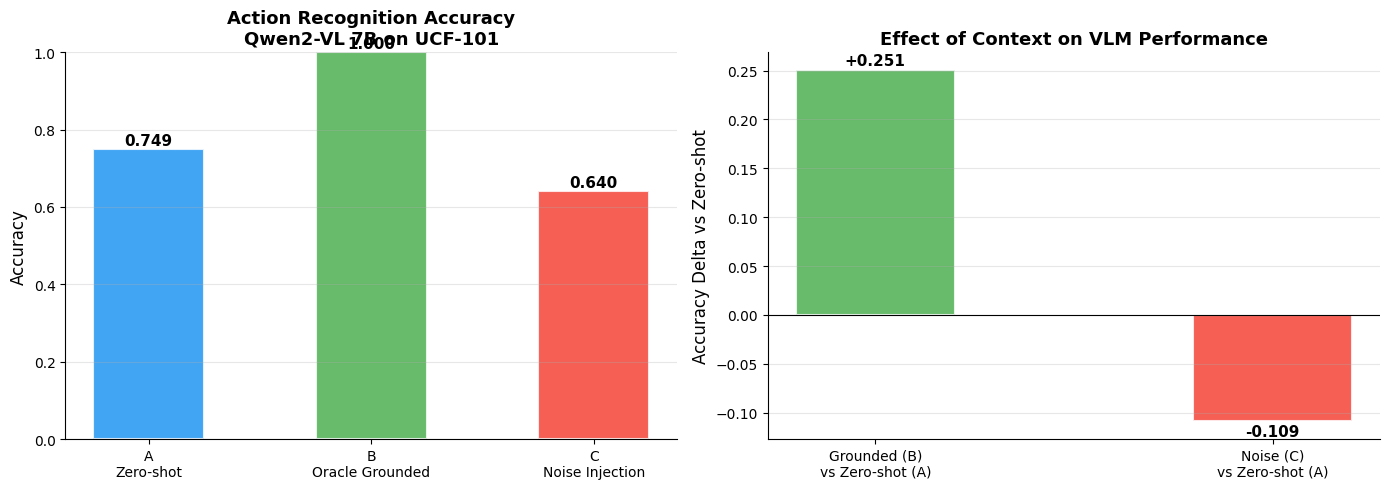

Saved to /kaggle/working/results.png


In [13]:
acc_A = tracker.accuracy('A')
acc_B = tracker.accuracy('B')
acc_C = tracker.accuracy('C')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy per condition
conds = ['A\nZero-shot', 'B\nOracle Grounded', 'C\nNoise Injection']
accs = [acc_A, acc_B, acc_C]
cols = ['#2196F3', '#4CAF50', '#F44336']
bars = axes[0].bar(conds, accs, color=cols, alpha=0.85, edgecolor='white', linewidth=1.5, width=0.5)
axes[0].set_ylim(0, 1.0)
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].set_title('Action Recognition Accuracy\nQwen2-VL 7B on UCF-101', fontsize=13, fontweight='bold')
for bar, acc in zip(bars, accs):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{acc:.3f}', ha='center', fontweight='bold', fontsize=11)
axes[0].grid(axis='y', alpha=0.3)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Delta from zero-shot
deltas = [acc_B - acc_A, acc_C - acc_A]
dlabels = ['Grounded (B)\nvs Zero-shot (A)', 'Noise (C)\nvs Zero-shot (A)']
dcols = ['#4CAF50' if d >= 0 else '#F44336' for d in deltas]
bars2 = axes[1].bar(dlabels, deltas, color=dcols, alpha=0.85, edgecolor='white', linewidth=1.5, width=0.4)
axes[1].axhline(y=0, color='black', linewidth=0.8)
axes[1].set_ylabel('Accuracy Delta vs Zero-shot', fontsize=12)
axes[1].set_title('Effect of Context on VLM Performance', fontsize=13, fontweight='bold')
for bar, d in zip(bars2, deltas):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + (0.005 if d >= 0 else -0.015),
                f'{d:+.3f}', ha='center', fontweight='bold', fontsize=11)
axes[1].grid(axis='y', alpha=0.3)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('/kaggle/working/results.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to /kaggle/working/results.png')

## 8. Qualitative Examples

In [15]:
def show_samples(results_df, ucf_root, n=6):
    """Display sample predictions with frames"""
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    axes = axes.flatten()
    shown = 0
    for _, row in results_df.iterrows():
        if shown >= n: break
        # Find video path
        video_path = ucf_root / row['ground_truth'] / row['video']
        frame = extract_middle_frame(video_path)
        if frame is None: continue
        ax = axes[shown]
        ax.imshow(frame)
        ax.axis('off')
        color_A = 'green' if row['hit_A'] else 'red'
        color_B = 'green' if row['hit_B'] else 'red'
        color_C = 'green' if row['hit_C'] else 'red'
        title = (
            f"GT: {row['ground_truth']}\n"
            f"A: {row['pred_A'][:30]}\n"
            f"B: {row['pred_B'][:30]}\n"
            f"C: {row['pred_C'][:30]}"
        )
        ax.set_title(title, fontsize=7, family='monospace')
        shown += 1
    plt.suptitle('Sample Predictions — Green=correct, A=zero-shot, B=grounded, C=noise', fontsize=10)
    plt.tight_layout()
    plt.savefig('/kaggle/working/qualitative.png', dpi=100, bbox_inches='tight')
    plt.show()

show_samples(results_df, UCF_ROOT)

NameError: name 'UCF_ROOT' is not defined

## 9. Per-Class Analysis

In [ ]:
# Which classes benefit most from grounding?
per_class = results_df.groupby('ground_truth').agg(
    acc_A=('hit_A', 'mean'),
    acc_B=('hit_B', 'mean'),
    acc_C=('hit_C', 'mean'),
    n=('hit_A', 'count')
).reset_index()
per_class['delta_B_A'] = per_class['acc_B'] - per_class['acc_A']
per_class = per_class.sort_values('delta_B_A', ascending=False)

print('Classes with biggest improvement from grounding (B vs A):')
print(per_class.head(10).to_string(index=False))
print()
print('Classes with biggest degradation from noise (C vs A):')
print(per_class.sort_values('delta_B_A').head(10).to_string(index=False))

per_class.to_csv('/kaggle/working/per_class_results.csv', index=False)

## 10. Key Findings

In [ ]:
print('KEY FINDINGS')
print('='*55)
print(f'A  Zero-shot accuracy      : {acc_A:.3f}')
print(f'B  Oracle grounded accuracy: {acc_B:.3f}  ({acc_B-acc_A:+.3f})')
print(f'C  Noise injection accuracy: {acc_C:.3f}  ({acc_C-acc_A:+.3f})')
print()
if acc_B > acc_A:
    print('FINDING 1: Oracle context IMPROVES Qwen2-VL performance')
    print('  VLMs benefit from accurate structured action priors')
else:
    print('FINDING 1: Oracle context does NOT improve performance')
    print('  VLMs rely primarily on visual features regardless of context')
print()
if acc_C < acc_A:
    print('FINDING 2: Noise injection DEGRADES performance')
    print('  Model genuinely uses provided context — not just visual features')
else:
    print('FINDING 2: Noise injection does NOT degrade performance')
    print('  Model appears to ignore text context — visual features dominate')
print()
print('Framework is model-agnostic.')
print('Pixtral 12B can replace Qwen2-VL when sufficient VRAM is available.')
print('Results saved to /kaggle/working/')